In [6]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions



In [7]:
df = pd.read_csv("placement.csv")

In [9]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [10]:
df.shape

(100, 4)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [12]:
df = df.iloc[:,1:]

In [13]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [14]:
import matplotlib.pyplot as plt

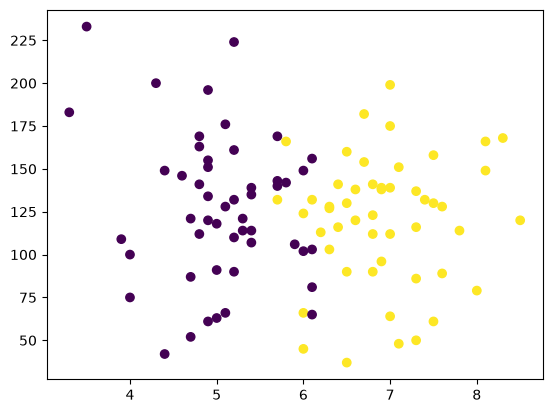

In [15]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])

In [16]:
x = df.iloc[:,0:2]

In [17]:
y = df.iloc[:,-1]

In [18]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [19]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [20]:
y.shape

(100,)

In [21]:
x.shape

(100, 2)

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1) 

In [23]:
x_train

,cgpa,iq
72,7.3,116.0
46,5.3,114.0
19,5.2,132.0
12,5.4,139.0
47,5.2,161.0
...,...,...
11,6.9,138.0
81,5.4,107.0
71,6.1,132.0
36,5.7,140.0


In [19]:
x_test

,cgpa,iq
46,5.3,114.0
15,5.1,176.0
32,7.0,139.0
92,5.2,110.0
95,4.3,200.0
77,7.3,50.0
88,4.4,149.0
9,5.1,66.0
89,4.9,151.0
90,7.3,86.0


In [24]:
y_train

72    1
46    0
19    0
12    0
47    0
     ..
11    1
81    0
71    1
36    0
85    1
Name: placement, Length: 90, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
x_train = scaler.fit_transform(x_train)

In [28]:
x_train

array([[ 1.10596816, -0.2780035 ],
       [-0.6972408 , -0.33034726],
       [-0.78740125,  0.14074654],
       [-0.60708035,  0.32394969],
       [-0.78740125,  0.899731  ],
       [ 0.83548682,  1.26613729],
       [ 0.83548682, -0.38269101],
       [ 0.56500547,  1.44934043],
       [-1.59884528,  1.92043423],
       [-1.32836393,  0.50715283],
       [ 1.37644951,  0.03605903],
       [ 0.02404279, -1.19401922],
       [ 1.28628906,  0.08840279],
       [-1.23820349, -1.95300368],
       [ 0.47484503,  0.29777781],
       [ 1.37644951, -0.9846442 ],
       [ 0.83548682,  0.32394969],
       [-0.96772214, -0.22565975],
       [ 0.65516592, -0.38269101],
       [ 0.83548682, -1.63894115],
       [-1.05788259, -0.17331599],
       [ 0.47484503, -0.17331599],
       [ 0.02404279, -0.61823791],
       [ 0.20436368,  0.00988715],
       [-0.87756169, -1.58659739],
       [ 1.28628906,  0.82121536],
       [-0.33659901,  1.10910602],
       [-1.86932662, -1.35105049],
       [ 1.28628906,

In [29]:
x_test = scaler.transform(x_test)

In [30]:
x_test


array([[-1.50868483, -2.21472246],
       [-1.86932662, -0.69675355],
       [ 0.38468458, -2.34558185],
       [ 0.92564727, -2.05769119],
       [-0.96772214, -0.93230045],
       [-0.33659901,  0.14074654],
       [-0.60708035, -0.33034726],
       [-2.50044976,  1.47551231],
       [ 0.20436368, -0.61823791],
       [-1.14804304, -0.38269101]])

In [31]:
clf = LogisticRegression()


In [32]:
print(type(clf))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [33]:
clf.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [34]:
y_pred = clf.predict(x_test)

In [35]:
y_test

96    0
18    0
82    1
5     1
25    0
87    1
41    0
17    0
98    1
59    0
Name: placement, dtype: int64

In [36]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy_score(y_test,y_pred)

1.0

In [3]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from mlxtend.plotting import plot_decision_regions

In [5]:
import mlxtend
print(mlxtend.__version__)

0.25.0


<Axes: >

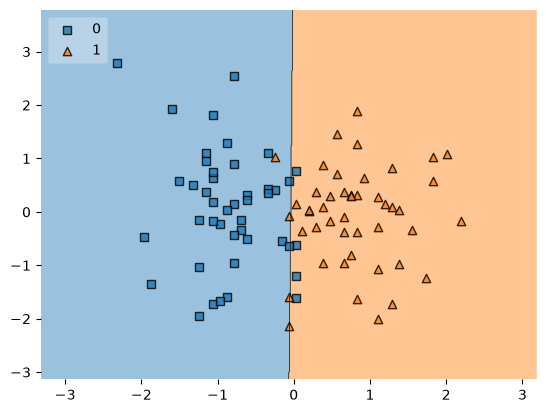

In [38]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [39]:
import pickle

In [40]:
pickle.dump(clf,open("model.pkl","wb"))